# Clase 23 — Datos, sesgos y cómo aprende una IA

**Diplomado IA Aplicada al Diseño · UDD · 2026** · Prof. Darío Osorio

Ejecuta las celdas en orden. Donde diga `# TU TURNO`, modifica lo indicado.

## Objetivos del notebook
1. Cargar y explorar un dataset real (reseñas en español).
2. Detectar visualmente balance de clases y valores faltantes.
3. Identificar un sesgo posible.

**Archivos necesarios**: `Clase_23_dataset_resenas_es.csv` (súbelo a Colab junto con este notebook, ver Paso 1).

## Paso 0 — Instalación


In [1]:
!pip install -q pandas matplotlib seaborn
print("Listo.")

Listo.


## Paso 1 — Subir y cargar el dataset

Este notebook usa un dataset local (`Clase_23_dataset_resenas_es.csv`), preparado por el profesor: 1000+ reseñas de productos en español, con distribución realista (desbalanceada) y algunos valores faltantes / duplicados a propósito, para que los detectes tú.

Antes de ejecutar la siguiente celda: `Archivo → Subir cuaderno` ya lo hiciste; ahora sube también el CSV con el ícono de carpeta (📁) a la izquierda → `Subir a almacenamiento de sesión` → selecciona `Clase_23_dataset_resenas_es.csv`.

In [8]:
import pandas as pd

# Dataset local (no depende de descargas externas ni de conexión inestable en vivo)
df = pd.read_csv("colesgeo.csv")

print(f"Cargadas {len(df)} filas")
print(f"Columnas disponibles: {df.columns.tolist()}")
df.head()

Cargadas 9273 filas
Columnas disponibles: ['Unnamed: 0', 'RBD', 'NOM_RBD', 'NOM_COM_RBD', 'query', 'lon', 'lat']


,Unnamed: 0,RBD,NOM_RBD,NOM_COM_RBD,query,lon,lat
0,1,1,LICEO POLITECNICO ARICA,ARICA,"LICEO POLITECNICO ARICA , ARICA",-70.294692,-18.487186
1,2,3,ESC. PEDRO VICENTE GUTIERREZ TORRES,ARICA,"ESC. PEDRO VICENTE GUTIERREZ TORRES , ARICA",-70.302775,-18.486958
2,3,4,LICEO OCTAVIO PALMA PEREZ,ARICA,"LICEO OCTAVIO PALMA PEREZ , ARICA",-70.307920,-18.474170
3,4,5,JOVINA NARANJO FERNANDEZ,ARICA,"JOVINA NARANJO FERNANDEZ , ARICA",-70.313452,-18.476804
4,5,7,L. POLI. ANTONIO VARAS DE LA BARRA,ARICA,"L. POLI. ANTONIO VARAS DE LA BARRA , ARICA",-70.287950,-18.475946


## Paso 2 — Ver 5 primeras filas

In [11]:
df[["NOM_RBD","NOM_COM_RBD","lon"]].head(5)

,NOM_RBD,NOM_COM_RBD,lon
0,LICEO POLITECNICO ARICA,ARICA,-70.294692
1,ESC. PEDRO VICENTE GUTIERREZ TORRES,ARICA,-70.302775
2,LICEO OCTAVIO PALMA PEREZ,ARICA,-70.307920
3,JOVINA NARANJO FERNANDEZ,ARICA,-70.313452
4,L. POLI. ANTONIO VARAS DE LA BARRA,ARICA,-70.287950


## Paso 3 — Cantidad de establecimientos por región

COMUNAS CON MAYOR CANTIDAD DE ESTABLECIMIENTOS:
NOM_COM_RBD
OLLAG�E             1
LAGUNA BLANCA       1
RIO VERDE           1
SAN GREGORIO        1
TORTEL              1
PRIMAVERA           1
O'HIGGINS           1
JUAN FERNANDEZ      1
ANTARTICA           1
SIERRA GORDA        2
COCHRANE            2
TORRES DEL PAINE    2
TIMAUKEL            2
GUAITECAS           2
CABO DE HORNOS      2
LA ESTRELLA         3
EL TABO             3
SAN ROSENDO         3
MARIA ELENA         3
PORVENIR            3
MEJILLONES          4
PICA                4
EMPEDRADO           4
PAPUDO              4
LAGO VERDE          4
ISLA DE PASCUA      4
RINCONADA           4
COLCHANE            5
LICANTEN            5
ALHUE               5
Name: count, dtype: int64


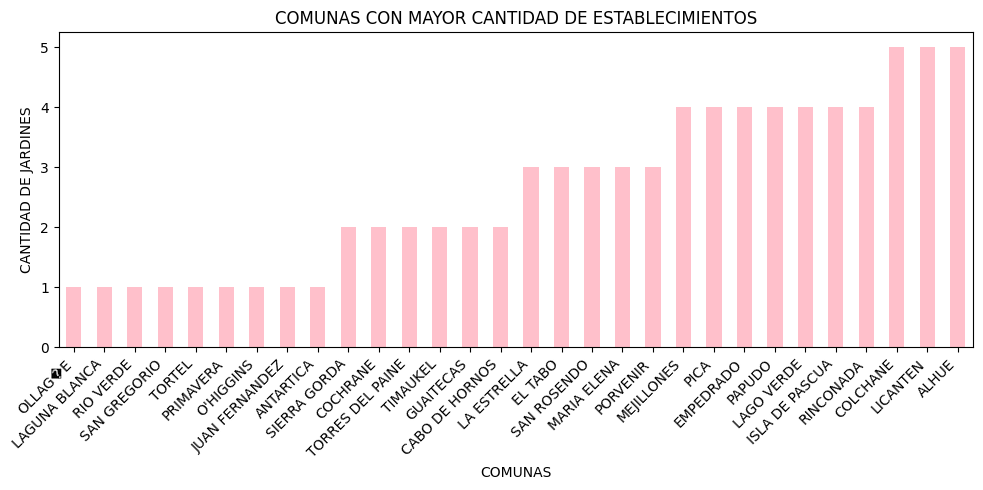


Ratio máxima/mínima: 148.00
Región con mayor cantidad: TEMUCO (148 establecimientos)
Región con menor cantidad: OLLAG�E (1 establecimientos)


In [18]:
import matplotlib.pyplot as plt

# Contar establecimientos por comuna
counts = df['NOM_COM_RBD'].value_counts()

# Seleccionar comunas con mayor cantidad
counts_mayores = counts.nsmallest(30)

print("COMUNAS CON MAYOR CANTIDAD DE ESTABLECIMIENTOS:")
print(counts_mayores)

# Gráfico
plt.figure(figsize=(10,5))
counts_mayores.plot(kind='bar', color='pink')

plt.title("COMUNAS CON MAYOR CANTIDAD DE ESTABLECIMIENTOS")
plt.xlabel("COMUNAS")
plt.ylabel("CANTIDAD DE JARDINES")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate ratio before printing
ratio = counts.max() / counts.min()

print(f"\nRatio máxima/mínima: {ratio:.2f}")
print(f"Región con mayor cantidad: {counts.idxmax()} ({counts.max()} establecimientos)")
print(f"Región con menor cantidad: {counts.idxmin()} ({counts.min()} establecimientos)")

## Paso 4 — Longitud de las reseñas por calificación

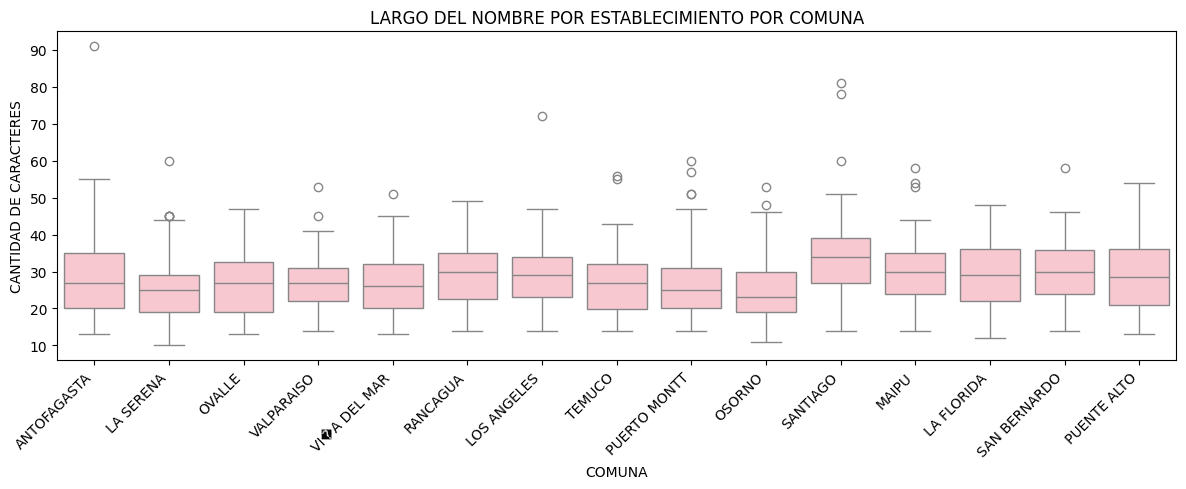

Observa: ¿Hay diferencias sistemáticas en el largo del nombre según la comuna?
Si: la comuna podría estar asociada a diferencias en la longitud de los nombres de los establecimientos.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular largo del nombre del establecimiento
df['largo'] = df['NOM_RBD'].astype(str).str.len()

# Seleccionar las 10 comunas con mayor cantidad de establecimientos
top_comunas = df['NOM_COM_RBD'].value_counts().head(15).index

df_top = df[df['NOM_COM_RBD'].isin(top_comunas)]

# Gráfico
plt.figure(figsize=(12,5))

sns.boxplot(x='NOM_COM_RBD', y='largo', data=df_top,color='pink')

plt.title("LARGO DEL NOMBRE POR ESTABLECIMIENTO POR COMUNA")
plt.xlabel("COMUNA")
plt.ylabel("CANTIDAD DE CARACTERES")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Observa: ¿Hay diferencias sistemáticas en el largo del nombre según la comuna?")
print("Si: la comuna podría estar asociada a diferencias en la longitud de los nombres de los establecimientos.")

## Paso 5 — Valores faltantes

In [25]:
print("Valores faltantes por columna:\n")
print(df.isnull().sum())

print("\nFilas con nombre de establecimiento vacío:",
      (df['NOM_RBD'].fillna('') == '').sum())

print("\nDuplicados por establecimiento y comuna:",
      df.duplicated(subset=['NOM_RBD', 'NOM_COM_RBD']).sum())

Valores faltantes por columna:

Unnamed: 0      0
RBD             0
NOM_RBD         0
NOM_COM_RBD     0
query           0
lon            95
lat            95
largo           0
dtype: int64

Filas con nombre de establecimiento vacío: 0

Duplicados por establecimiento y comuna: 22


## TU TURNO — bitácora

Anota en la bitácora de tu proyecto:

1. ¿Cuál es la clase más representada? ¿Cuál la menos?
2. ¿Hay patrones de largo del texto que podrían ser un sesgo?
3. ¿Cómo se ve el equilibrio de tu propio dataset comparado con éste?

## Cierre
Guarda copia (`Archivo → Guardar copia en Drive`), descargala y súbela a tu repo en `notebooks/Clase_23.ipynb`.